## Section 0 — Repo Setup

The inner repo clone already exists at `notebooks/temporal-awareness/`.  
This cell is a no-op for local execution.

In [1]:
# Repo already cloned locally — skip git clone/checkout
print("Using local repo at notebooks/temporal-awareness/")

Using local repo at notebooks/temporal-awareness/


## Section 1 — Install Dependencies

Installs the repo as an editable package so all `src.*` imports work.  
**After this cell finishes: Runtime → Restart runtime, then continue from Section 2.**

In [2]:
# Dependencies already installed in the venv — skip pip install
print("Using existing venv dependencies.")

Using existing venv dependencies.


## Section 2 — Imports & Configuration

All Python imports in one place.  
Make sure the runtime has been restarted after Section 1.

In [3]:
import json
import os
import sys
from pathlib import Path

import torch
from transformer_lens import HookedTransformer
from transformers import AutoModelForCausalLM, AutoTokenizer
from huggingface_hub import login

# ── Make sure we're in the inner repo root ────────────────────────────────
REPO_ROOT = Path('/home/marshall/Documents/temporal-project/notebooks/temporal-awareness')
os.chdir(REPO_ROOT)

# Add repo to sys.path so src.* imports work
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.inference.model_runner import ModelRunner
from src.inference.backends import ModelBackend
from src.inference.backends.transformerlens import TransformerLensBackend

# ── Constants ─────────────────────────────────────────────────────────────
MODEL_NAME            = "Qwen/Qwen3-4B-Instruct-2507"
DATASET_PATH          = Path("data/raw/temporal_scope_AB_randomized/temporal_scope_explicit_expanded_500.json")
IMPLICIT_DATASET_PATH = Path("data/raw/temporal_scope_AB_randomized/temporal_scope_implicit_expanded_300.json")
OUT_DIR               = REPO_ROOT / 'out' / 'steering_from_scratch'

print("Imports OK.")
print(f"  torch  : {torch.__version__}")
print(f"  device : {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"  model  : {MODEL_NAME}")

Imports OK.
  torch  : 2.9.1+cu128
  device : cuda
  model  : Qwen/Qwen3-4B-Instruct-2507


## Section 3 — Auth & Google Drive

- Logs in to Hugging Face (needed to download the gated Qwen model).
- Mounts Google Drive and symlinks `out/` so all experiment artifacts persist across sessions.

In [4]:
# ── Hugging Face login ─────────────────────────────────────────────────────
# Try env var first, then cached token, then prompt
import os
hf_token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGING_FACE_HUB_TOKEN")
if hf_token:
    login(token=hf_token)
    print("HF login OK (from env var).")
else:
    try:
        from huggingface_hub import HfFolder
        if HfFolder.get_token():
            print("HF login OK (cached token).")
        else:
            raise ValueError("No cached token")
    except Exception:
        from getpass import getpass
        hf_token = getpass("Hugging Face token (hidden): ")
        login(token=hf_token)
        print("HF login OK.")

# ── Local output dir (no Google Drive) ─────────────────────────────────────
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Artifacts → {OUT_DIR}")

HF login OK (cached token).
Artifacts → /home/marshall/Documents/temporal-project/notebooks/temporal-awareness/out/steering_from_scratch


## Section 4 — Datasets

- **Explicit** (`temporal_scope_explicit_expanded_500.json`) — 500 A/B pairs with explicit short-term vs long-term framing.
- **Implicit** (`temporal_scope_implicit_expanded_300.json`) — 300 A/B pairs where the temporal scope is implied.

In [5]:
for p in (DATASET_PATH, IMPLICIT_DATASET_PATH):
    if not p.exists():
        raise FileNotFoundError(f"Dataset not found: {p}")

with open(DATASET_PATH)  as f: explicit_ds = json.load(f)
with open(IMPLICIT_DATASET_PATH) as f: implicit_ds = json.load(f)

explicit_pairs = explicit_ds.get('pairs', [])
implicit_pairs = implicit_ds.get('pairs', [])

print(f"Explicit pairs : {len(explicit_pairs)}")
print(f"Implicit pairs : {len(implicit_pairs)}")
print("\nExplicit sample:", explicit_pairs[0])
print("\nImplicit sample:", implicit_pairs[0])

Explicit pairs : 500
Implicit pairs : 300

Explicit sample: {'id': 1, 'category': 'planning', 'question': 'When developing a roadmap for this initiative, consider:', 'immediate': ' (A) What we can deliver in the next 30 days', 'long_term': ' (B) What position we want in 10 years'}

Implicit sample: {'id': 1, 'question': 'When the system fails, the first priority becomes', 'immediate': ' (A) containing the spreading damage before it escalates', 'long_term': ' (B) redesigning the architecture to prevent recurrence', 'category': 'crisis_vs_foundation'}


## Section 5 — Model Loading

`Qwen/Qwen3-4B-Instruct-2507` is not in TransformerLens's model registry, but `Qwen/Qwen3-4B`
(same architecture, different weights) is.  
We monkey-patch `ModelRunner._init_transformerlens` with an arch-mapping table so the rest of
the notebook can use the identical one-liner that `06_probing_and_steering.ipynb` uses for Llama:

```python
runner = ModelRunner(MODEL_NAME, backend=ModelBackend.TRANSFORMERLENS, dtype=torch.float16)
```

In [6]:
# ── Arch-mapping table (extend if you switch models later) ────────────────
TL_ARCH_MAP = {
    "Qwen/Qwen3-4B-Instruct-2507": "Qwen/Qwen3-4B",
}

def _patched_init_transformerlens(self) -> None:
    arch_ref   = TL_ARCH_MAP.get(self.model_name, self.model_name)
    in_registry = (arch_ref == self.model_name)

    print(f"Loading {self.model_name} on {self.device} (TransformerLens)...")

    if in_registry:
        self._model = HookedTransformer.from_pretrained_no_processing(
            self.model_name, device=self.device, dtype=self.dtype
        )
    else:
        print(f"  arch ref → {arch_ref}")
        hf_model  = AutoModelForCausalLM.from_pretrained(
            self.model_name, torch_dtype=self.dtype, device_map="cpu"
        )
        tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        self._model = HookedTransformer.from_pretrained(
            arch_ref,
            hf_model=hf_model,
            tokenizer=tokenizer,
            dtype=self.dtype,
            move_to_device=True,
            fold_ln=False,
            center_writing_weights=False,
            center_unembed=False,
        )
        del hf_model

    self._model.eval()
    self._backend = TransformerLensBackend(self)

ModelRunner._init_transformerlens = _patched_init_transformerlens
print("Patch applied.")

Patch applied.


In [7]:
runner = ModelRunner(
    MODEL_NAME,
    backend=ModelBackend.TRANSFORMERLENS,
    dtype=torch.float16,
)

N_LAYERS = runner.n_layers
D_MODEL  = runner.d_model

print(f"n_layers = {N_LAYERS}")
print(f"d_model  = {D_MODEL}")

Loading Qwen/Qwen3-4B-Instruct-2507 on cuda (TransformerLens)...
  arch ref → Qwen/Qwen3-4B


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen3-4B into HookedTransformer


Model loaded: ModelBackend.TRANSFORMERLENS Qwen/Qwen3-4B-Instruct-2507 (chat=True)
  n_layers=36, d_model=2560

n_layers = 36
d_model  = 2560


In [8]:
# ── Forward-pass sanity check ──────────────────────────────────────────────
logits, cache = runner.run_with_cache(
    "When planning under uncertainty, prioritize:",
    names_filter=lambda n: "hook_resid_post" in n,
)

assert len(cache) == N_LAYERS, f"Expected {N_LAYERS} cached tensors, got {len(cache)}"
act_shape = tuple(list(cache.values())[0].shape)
assert act_shape[-1] == D_MODEL, f"d_model mismatch: {act_shape}"

print("Sanity check passed.")
print(f"  logits : {tuple(logits.shape)}")
print(f"  cache  : {len(cache)} tensors, each {act_shape}")

Sanity check passed.
  logits : (1, 15, 151936)
  cache  : 36 tensors, each (1, 15, 2560)


## Section 6 — Probing

**Goal**: find the layer where the model linearly encodes the temporal concept
(short-term vs long-term) most clearly.

**Protocol** (identical to `06_probing_and_steering.ipynb`):

1. Build prompts by concatenating `question + choice` for every pair.
2. Extract last-token residual-stream activations at every layer — shape `[n, n_layers, d_model]`.
3. Train one `LogisticRegression(C=0.1)` probe per layer on the **implicit** dataset (80/20 split).
4. Plot test accuracy per layer → identify the peak layer.
5. Zero-shot evaluate those same probes on the **explicit** dataset to test cross-dataset generalisation.

The **implicit** dataset has no surface time-words, so the probe direction captures
semantic temporal reasoning rather than keyword patterns.

In [9]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scripts.week1.activation_extractor import extract_activations_for_prompts

PROBE_OUT_DIR = OUT_DIR / "probing"
PROBE_OUT_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE  = 42

print(f"Probe artifacts → {PROBE_OUT_DIR}")

Probe artifacts → /home/marshall/Documents/temporal-project/notebooks/temporal-awareness/out/steering_from_scratch/probing


In [10]:
# ── Build prompts (question + choice concatenation, same as notebook 06) ──
impl_immediate = [p["question"] + p["immediate"] for p in implicit_pairs]
impl_long_term = [p["question"] + p["long_term"]  for p in implicit_pairs]
expl_immediate = [p["question"] + p["immediate"] for p in explicit_pairs]
expl_long_term = [p["question"] + p["long_term"]  for p in explicit_pairs]

N_IMPL = len(implicit_pairs)
N_EXPL = len(explicit_pairs)

print(f"Implicit : {N_IMPL} pairs  ({N_IMPL*2} prompts)")
print(f"Explicit : {N_EXPL} pairs  ({N_EXPL*2} prompts)")
print(f"\nImplicit immediate[0]: {impl_immediate[1]!r}")
print(f"Implicit long-term[0]: {impl_long_term[1]!r}")

Implicit : 300 pairs  (600 prompts)
Explicit : 500 pairs  (1000 prompts)

Implicit immediate[0]: 'The hospital administrator directs resources toward (B) stabilizing patients in critical condition'
Implicit long-term[0]: 'The hospital administrator directs resources toward (A) training staff and upgrading medical equipment'


In [11]:
# ── Token-position sanity check ───────────────────────────────────────────
# The Qwen chat template wraps every prompt as:
#
#   <|im_start|>system\n...<|im_end|>\n
#   <|im_start|>user\n<choice text><|im_end|>\n
#   <|im_start|>assistant\n
#
# So position -1 is the trailing '\n' of the assistant turn, NOT the choice text.
# extract_activations_for_prompts (scripts/week1/activation_extractor.py) now
# finds the last <|im_end|> in the sequence and reads position (last_im_end - 1),
# which is the final token of the choice text.
#
# Run this cell to confirm the target index looks correct for the first prompt.

_raw      = impl_immediate[0]
_fmt      = runner.apply_chat_template(_raw)
_ids      = runner.encode(_fmt)[0].tolist()
_tokens   = runner._model.tokenizer.convert_ids_to_tokens(_ids)
_im_end   = runner._model.tokenizer.convert_tokens_to_ids("<|im_end|>")
_last_pos = max(i for i, t in enumerate(_ids) if t == _im_end)
_target   = _last_pos - 1

print(f"Sequence length : {len(_ids)} tokens")
print(f"Last <|im_end|> : position {_last_pos}  → token {repr(_tokens[_last_pos])}")
print(f"Target position : {_target}              → token {repr(_tokens[_target])}")
print()
print("Context around target:")
for i in range(max(0, _target - 3), min(len(_ids), _target + 4)):
    marker = " ◄ TARGET" if i == _target else ""
    print(f"  {i:>4}  {_ids[i]:>10}  {repr(_tokens[i])}{marker}")

Sequence length : 28 tokens
Last <|im_end|> : position 23  → token '<|im_end|>'
Target position : 22              → token 'ates'

Context around target:
    19        1573  'Ġbefore'
    20         432  'Ġit'
    21       26435  'Ġescal'
    22         973  'ates' ◄ TARGET
    23      151645  '<|im_end|>'
    24         198  'Ċ'
    25      151644  '<|im_start|>'


In [12]:
# ── Extract implicit activations ──────────────────────────────────────────
# Shape: [n_prompts, n_layers, d_model]
acts_impl_imm = extract_activations_for_prompts(runner, impl_immediate, desc="Implicit  immediate")
acts_impl_lt  = extract_activations_for_prompts(runner, impl_long_term,  desc="Implicit  long-term")

assert torch.isfinite(acts_impl_imm).all() and torch.isfinite(acts_impl_lt).all(), \
    "Non-finite values in implicit activations!"

print(f"Implicit immediate : {tuple(acts_impl_imm.shape)}")
print(f"Implicit long-term : {tuple(acts_impl_lt.shape)}")
print("Finite check: OK")

Implicit  immediate:   0%|          | 0/300 [00:00<?, ?it/s]

Implicit  immediate:   0%|          | 1/300 [00:00<00:46,  6.50it/s]

Implicit  immediate:   1%|          | 2/300 [00:00<00:46,  6.44it/s]

Implicit  immediate:   1%|          | 3/300 [00:00<00:46,  6.32it/s]

Implicit  immediate:   1%|▏         | 4/300 [00:00<00:47,  6.29it/s]

...

Implicit  long-term:  99%|█████████▉| 298/300 [00:46<00:00,  6.38it/s]

Implicit  long-term: 100%|█████████▉| 299/300 [00:46<00:00,  6.48it/s]

Implicit  long-term: 100%|██████████| 300/300 [00:46<00:00,  6.42it/s]

Implicit  long-term: 100%|██████████| 300/300 [00:46<00:00,  6.45it/s]

Implicit immediate : (300, 36, 2560)
Implicit long-term : (300, 36, 2560)
Finite check: OK


In [13]:
# ── Extract explicit activations ──────────────────────────────────────────
acts_expl_imm = extract_activations_for_prompts(runner, expl_immediate, desc="Explicit  immediate")
acts_expl_lt  = extract_activations_for_prompts(runner, expl_long_term,  desc="Explicit  long-term")

assert torch.isfinite(acts_expl_imm).all() and torch.isfinite(acts_expl_lt).all(), \
    "Non-finite values in explicit activations!"

print(f"Explicit immediate : {tuple(acts_expl_imm.shape)}")
print(f"Explicit long-term : {tuple(acts_expl_lt.shape)}")
print("Finite check: OK")

Explicit  immediate:   0%|          | 0/500 [00:00<?, ?it/s]

Explicit  immediate:   0%|          | 1/500 [00:00<01:29,  5.55it/s]

Explicit  immediate:   0%|          | 2/500 [00:00<01:20,  6.19it/s]

Explicit  immediate:   1%|          | 3/500 [00:00<01:19,  6.26it/s]

Explicit  immediate:   1%|          | 4/500 [00:00<01:21,  6.11it/s]

...

Explicit  long-term: 100%|█████████▉| 498/500 [01:17<00:00,  6.50it/s]

Explicit  long-term: 100%|█████████▉| 499/500 [01:17<00:00,  6.48it/s]

Explicit  long-term: 100%|██████████| 500/500 [01:17<00:00,  6.43it/s]

Explicit  long-term: 100%|██████████| 500/500 [01:17<00:00,  6.46it/s]

Explicit immediate : (500, 36, 2560)
Explicit long-term : (500, 36, 2560)
Finite check: OK


In [14]:
# ── Train probes (both scaled and raw) on implicit data — pair-aware split ──
# Rows 0..N_IMPL-1 = immediate activations, N_IMPL..2*N_IMPL-1 = long_term.
X_impl = torch.cat([acts_impl_imm, acts_impl_lt], dim=0).float().numpy()

pair_idx = np.arange(N_IMPL)
train_idx, test_idx = train_test_split(
    pair_idx, test_size=0.2, random_state=RANDOM_STATE,
)

results_scaled, results_raw = [], []

for layer in tqdm(range(N_LAYERS), desc="Training probes (scaled + raw)"):
    X_layer = X_impl[:, layer, :]

    X_train = np.concatenate([X_layer[train_idx], X_layer[train_idx + N_IMPL]], axis=0)
    X_test  = np.concatenate([X_layer[test_idx],  X_layer[test_idx  + N_IMPL]], axis=0)
    y_train = np.array([0] * len(train_idx) + [1] * len(train_idx))
    y_test  = np.array([0] * len(test_idx)  + [1] * len(test_idx))

    # ── scaled mode ─────────────────────────────────────────────────────────
    scaler  = StandardScaler()
    Xtr_s   = scaler.fit_transform(X_train)
    Xte_s   = scaler.transform(X_test)
    probe_s = LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_STATE)
    probe_s.fit(Xtr_s, y_train)
    with open(PROBE_OUT_DIR / f"scaler_layer_{layer:02d}.pkl", "wb") as fh:
        pickle.dump(scaler, fh)
    with open(PROBE_OUT_DIR / f"probe_scaled_layer_{layer:02d}.pkl", "wb") as fh:
        pickle.dump(probe_s, fh)
    results_scaled.append({"layer": layer, "test_accuracy": probe_s.score(Xte_s, y_test),
                            "n_train": len(y_train), "n_test": len(y_test)})

    # ── raw mode (no scaling) ────────────────────────────────────────────────
    probe_r = LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_STATE)
    probe_r.fit(X_train, y_train)
    with open(PROBE_OUT_DIR / f"probe_raw_layer_{layer:02d}.pkl", "wb") as fh:
        pickle.dump(probe_r, fh)
    results_raw.append({"layer": layer, "test_accuracy": probe_r.score(X_test, y_test),
                        "n_train": len(y_train), "n_test": len(y_test)})

df_scaled = pd.DataFrame(results_scaled)
df_raw    = pd.DataFrame(results_raw)
df_probes = df_scaled.copy()   # canonical df used by downstream cells (scaled is recommended)

df_scaled.to_csv(PROBE_OUT_DIR / "probe_accuracies_scaled.csv", index=False)
df_raw.to_csv(PROBE_OUT_DIR / "probe_accuracies_raw.csv", index=False)

print("── Scaled ──────────────────────────────────")
print(df_scaled.to_string(index=False))
print("\n── Raw (no scaling) ────────────────────────")
print(df_raw.to_string(index=False))

Training probes (scaled + raw):   0%|          | 0/36 [00:00<?, ?it/s]

Training probes (scaled + raw):   3%|▎         | 1/36 [00:02<01:19,  2.27s/it]

Training probes (scaled + raw):   6%|▌         | 2/36 [00:04<01:22,  2.44s/it]

Training probes (scaled + raw):   8%|▊         | 3/36 [00:07<01:24,  2.56s/it]

Training probes (scaled + raw):  11%|█         | 4/36 [00:10<01:28,  2.75s/it]

...

Training probes (scaled + raw):  94%|█████████▍| 34/36 [01:21<00:06,  3.09s/it]

Training probes (scaled + raw):  97%|█████████▋| 35/36 [01:25<00:03,  3.28s/it]

Training probes (scaled + raw): 100%|██████████| 36/36 [01:29<00:00,  3.56s/it]

Training probes (scaled + raw): 100%|██████████| 36/36 [01:29<00:00,  2.48s/it]

── Scaled ──────────────────────────────────
 layer  test_accuracy  n_train  n_test
     0       0.808333      480     120
     1       0.850000      480     120
     2       0.841667      480     120
     3       0.858333      480     120
     4       0.825000      480     120
     5       0.841667      480     120
     6       0.891667      480     120
     7       0.925000      480     120
     8       0.933333      480     120
     9       0.950000      480     120
    10       0.941667      480     120
    11       0.941667      480     120
    12       0.933333      480     120
    13       0.933333      480     120
    14       0.966667      480     120
    15       0.958333      480     120
    16       0.966667      480     120
    17       0.983333      480     120
    18       0.975000      480     120
    19       0.975000      480     120
    20       0.975000      480     120
    21       0.975000      480     120
    22       0.975000      480     120
    23       0.9833

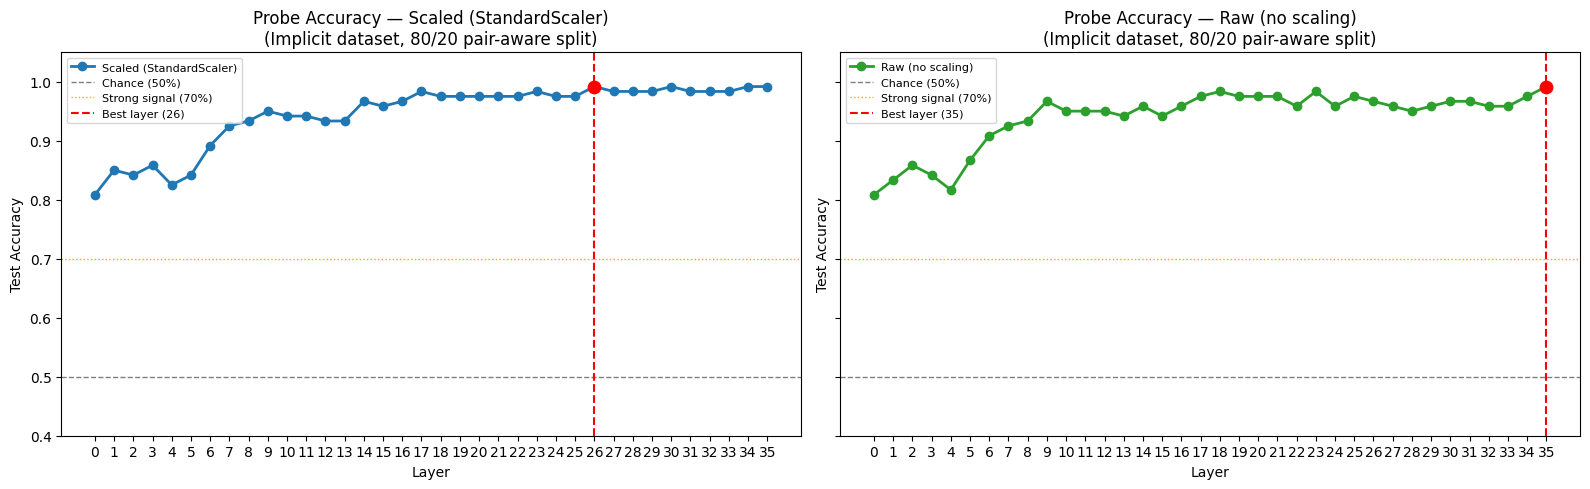

Scaled  → best layer 26  acc 0.992
Raw     → best layer 35  acc 0.992

Using layer 26 (scaled) for downstream steering.


In [15]:
# ── Plot: scaled vs raw implicit test accuracy ────────────────────────────
best_layer_s = int(df_scaled["layer"].iloc[df_scaled["test_accuracy"].idxmax()])
best_layer_r = int(df_raw["layer"].iloc[df_raw["test_accuracy"].idxmax()])
best_layer   = best_layer_s   # used by downstream cells

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, df, label, color, best, fname in [
    (axes[0], df_scaled, "Scaled (StandardScaler)", "tab:blue",
     best_layer_s, "probe_accuracy_scaled.png"),
    (axes[1], df_raw,    "Raw (no scaling)",         "tab:green",
     best_layer_r, "probe_accuracy_raw.png"),
]:
    best_acc = df.loc[df["test_accuracy"].idxmax(), "test_accuracy"]
    ax.plot(df["layer"], df["test_accuracy"], marker="o", linewidth=2,
            color=color, label=label)
    ax.axhline(0.5, color="gray",   linestyle="--", linewidth=1, label="Chance (50%)")
    ax.axhline(0.7, color="orange", linestyle=":",  linewidth=1, label="Strong signal (70%)")
    ax.axvline(best, color="red", linestyle="--", linewidth=1.5,
               label=f"Best layer ({best})")
    ax.scatter([best], [best_acc], color="red", zorder=5, s=80)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Test Accuracy")
    ax.set_title(f"Probe Accuracy — {label}\n(Implicit dataset, 80/20 pair-aware split)")
    ax.legend(fontsize=8)
    ax.set_ylim(0.4, 1.05)
    ax.set_xticks(range(N_LAYERS))
    plt.gcf().savefig(PROBE_OUT_DIR / fname, dpi=150, bbox_inches="tight")

plt.tight_layout()
plt.savefig(PROBE_OUT_DIR / "probe_accuracy_comparison.png", dpi=150)
plt.show()

print(f"Scaled  → best layer {best_layer_s}  acc {df_scaled['test_accuracy'].max():.3f}")
print(f"Raw     → best layer {best_layer_r}  acc {df_raw['test_accuracy'].max():.3f}")
print(f"\nUsing layer {best_layer} (scaled) for downstream steering.")

In [16]:
# ── Cross-dataset evaluation: apply implicit probes to explicit data ───────
X_expl = torch.cat([acts_expl_imm, acts_expl_lt], dim=0).float().numpy()
y_expl = np.array([0] * N_EXPL + [1] * N_EXPL)

cross_scaled, cross_raw = [], []

for layer in range(N_LAYERS):
    X_layer_expl = X_expl[:, layer, :]

    # scaled
    with open(PROBE_OUT_DIR / f"scaler_layer_{layer:02d}.pkl", "rb") as fh:
        scaler = pickle.load(fh)
    with open(PROBE_OUT_DIR / f"probe_scaled_layer_{layer:02d}.pkl", "rb") as fh:
        probe_s = pickle.load(fh)
    cross_scaled.append(probe_s.score(scaler.transform(X_layer_expl), y_expl))

    # raw
    with open(PROBE_OUT_DIR / f"probe_raw_layer_{layer:02d}.pkl", "rb") as fh:
        probe_r = pickle.load(fh)
    cross_raw.append(probe_r.score(X_layer_expl, y_expl))

df_scaled["cross_dataset_accuracy"] = cross_scaled
df_raw["cross_dataset_accuracy"]    = cross_raw
df_probes = df_scaled.copy()

df_scaled.to_csv(PROBE_OUT_DIR / "probe_accuracies_scaled.csv", index=False)
df_raw.to_csv(PROBE_OUT_DIR / "probe_accuracies_raw.csv", index=False)
print("Cross-dataset evaluation complete (both modes).")

Cross-dataset evaluation complete (both modes).


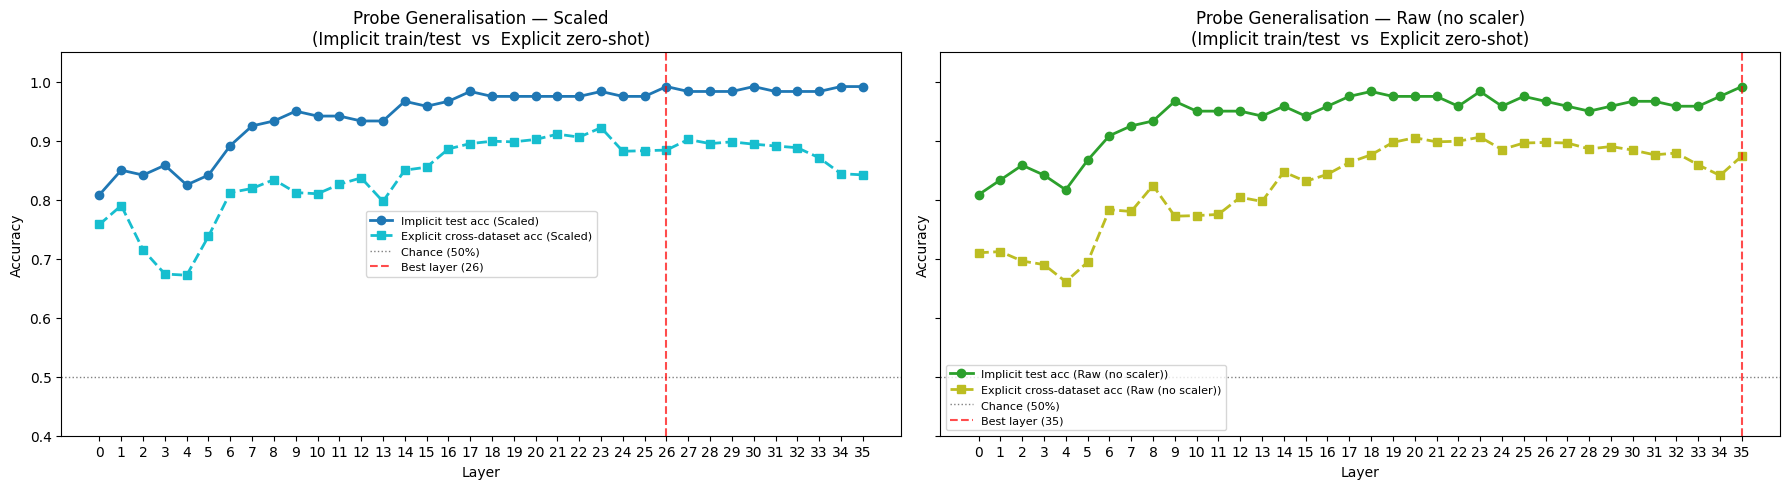


Mode       Best layer   Impl acc  Cross acc      Gap
------------------------------------------------
Scaled             26      0.992      0.884    0.108
Raw                35      0.992      0.874    0.118


In [17]:
# ── Plot: all four curves — scaled and raw, implicit and cross-dataset ─────
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

for ax, df, mode, c_impl, c_cross, best in [
    (axes[0], df_scaled, "Scaled",       "tab:blue",  "tab:cyan",  best_layer_s),
    (axes[1], df_raw,    "Raw (no scaler)", "tab:green", "tab:olive", best_layer_r),
]:
    ax.plot(df["layer"], df["test_accuracy"],
            marker="o", linewidth=2, color=c_impl,
            label=f"Implicit test acc ({mode})")
    ax.plot(df["layer"], df["cross_dataset_accuracy"],
            marker="s", linewidth=2, color=c_cross, linestyle="--",
            label=f"Explicit cross-dataset acc ({mode})")
    ax.axhline(0.5, color="gray", linestyle=":", linewidth=1, label="Chance (50%)")
    ax.axvline(best, color="red", linestyle="--", linewidth=1.5, alpha=0.7,
               label=f"Best layer ({best})")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Probe Generalisation — {mode}\n(Implicit train/test  vs  Explicit zero-shot)")
    ax.legend(fontsize=8)
    ax.set_ylim(0.4, 1.05)
    ax.set_xticks(range(N_LAYERS))

plt.tight_layout()
plt.savefig(PROBE_OUT_DIR / "probe_generalization_both_modes.png", dpi=150)
plt.show()

print(f"\n{'Mode':<10} {'Best layer':>10} {'Impl acc':>10} {'Cross acc':>10} {'Gap':>8}")
print("-" * 48)
for label, df, best in [("Scaled", df_scaled, best_layer_s), ("Raw", df_raw, best_layer_r)]:
    impl  = df.loc[df["layer"] == best, "test_accuracy"].values[0]
    cross = df.loc[df["layer"] == best, "cross_dataset_accuracy"].values[0]
    print(f"{label:<10} {best:>10} {impl:>10.3f} {cross:>10.3f} {impl-cross:>8.3f}")

Shuffled-label control:   0%|          | 0/36 [00:00<?, ?it/s]

Shuffled-label control:   3%|▎         | 1/36 [00:13<07:40, 13.16s/it]

Shuffled-label control:   6%|▌         | 2/36 [00:25<07:15, 12.82s/it]

Shuffled-label control:   8%|▊         | 3/36 [00:36<06:36, 12.03s/it]

Shuffled-label control:  11%|█         | 4/36 [00:48<06:24, 12.03s/it]

...

Shuffled-label control:  92%|█████████▏| 33/36 [04:55<00:28,  9.58s/it]

Shuffled-label control:  94%|█████████▍| 34/36 [05:06<00:20, 10.07s/it]

Shuffled-label control:  97%|█████████▋| 35/36 [05:19<00:10, 10.86s/it]

Shuffled-label control: 100%|██████████| 36/36 [05:30<00:00, 10.97s/it]

Shuffled-label control: 100%|██████████| 36/36 [05:30<00:00,  9.17s/it]

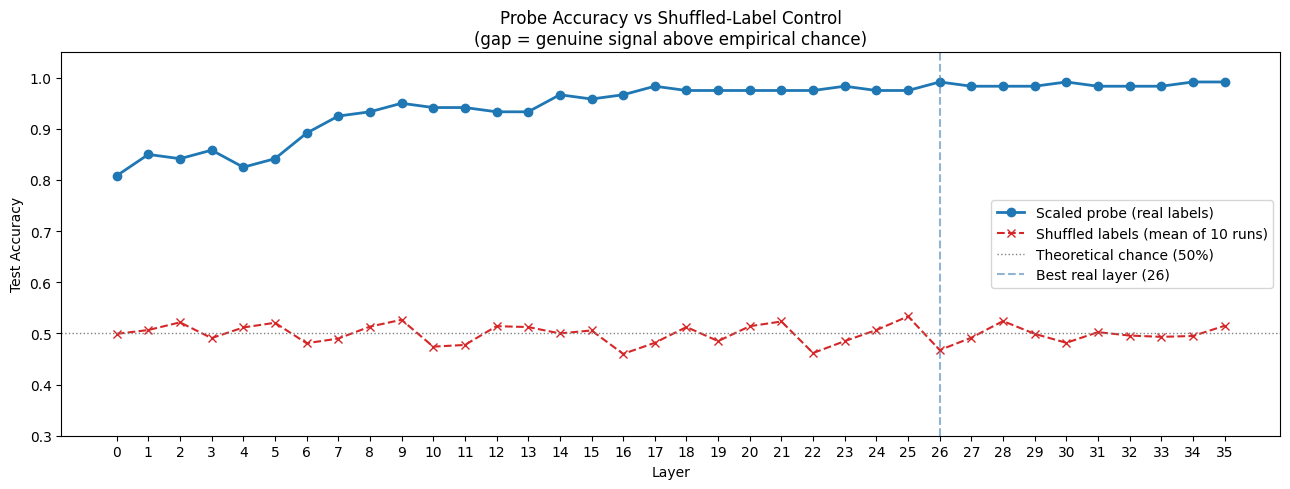

At best layer (26):
  Real scaled accuracy  : 0.992
  Shuffled mean accuracy: 0.468
  Signal above chance   : 0.524


In [18]:
# ── Shuffled-label control: empirical chance baseline ─────────────────────
# For each layer, train 10 probes on randomly permuted y_train (same scaled
# X_train) and score on the real y_test.  The mean accuracy gives the true
# chance level for this dataset — any genuine signal should sit we
# ll above it.

N_SHUFFLES = 10
rng = np.random.default_rng(RANDOM_STATE)

shuffle_results = []

for layer in tqdm(range(N_LAYERS), desc="Shuffled-label control"):
    X_layer = X_impl[:, layer, :]

    X_train_raw = np.concatenate([X_layer[train_idx], X_layer[train_idx + N_IMPL]], axis=0)
    X_test_raw  = np.concatenate([X_layer[test_idx],  X_layer[test_idx  + N_IMPL]], axis=0)
    y_train = np.array([0] * len(train_idx) + [1] * len(train_idx))
    y_test  = np.array([0] * len(test_idx)  + [1] * len(test_idx))

    # Use the same scaler that was fit during the real training
    with open(PROBE_OUT_DIR / f"scaler_layer_{layer:02d}.pkl", "rb") as fh:
        scaler = pickle.load(fh)
    X_train_s = scaler.transform(X_train_raw)
    X_test_s  = scaler.transform(X_test_raw)

    accs = []
    for _ in range(N_SHUFFLES):
        y_shuffled = rng.permutation(y_train)
        probe_shuf = LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_STATE)
        probe_shuf.fit(X_train_s, y_shuffled)
        accs.append(probe_shuf.score(X_test_s, y_test))

    shuffle_results.append({"layer": layer, "shuffle_mean_acc": float(np.mean(accs))})

df_shuffle = pd.DataFrame(shuffle_results)
df_shuffle.to_csv(PROBE_OUT_DIR / "probe_shuffle_control.csv", index=False)

# ── Plot: real scaled accuracy vs shuffled-label baseline ─────────────────
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df_scaled["layer"], df_scaled["test_accuracy"],
        marker="o", linewidth=2, color="tab:blue", label="Scaled probe (real labels)")
ax.plot(df_shuffle["layer"], df_shuffle["shuffle_mean_acc"],
        marker="x", linewidth=1.5, color="tab:red", linestyle="--",
        label=f"Shuffled labels (mean of {N_SHUFFLES} runs)")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1, label="Theoretical chance (50%)")
ax.axvline(best_layer_s, color="steelblue", linestyle="--", linewidth=1.5, alpha=0.6,
           label=f"Best real layer ({best_layer_s})")

ax.set_xlabel("Layer")
ax.set_ylabel("Test Accuracy")
ax.set_title("Probe Accuracy vs Shuffled-Label Control\n(gap = genuine signal above empirical chance)")
ax.legend()
ax.set_ylim(0.3, 1.05)
ax.set_xticks(range(N_LAYERS))
plt.tight_layout()
plt.savefig(PROBE_OUT_DIR / "probe_shuffle_control.png", dpi=150)
plt.show()

gap_at_best = (df_scaled.loc[df_scaled["layer"] == best_layer_s, "test_accuracy"].values[0]
               - df_shuffle.loc[df_shuffle["layer"] == best_layer_s, "shuffle_mean_acc"].values[0])
print(f"At best layer ({best_layer_s}):")
print(f"  Real scaled accuracy  : {df_scaled.loc[df_scaled['layer']==best_layer_s, 'test_accuracy'].values[0]:.3f}")
print(f"  Shuffled mean accuracy: {df_shuffle.loc[df_shuffle['layer']==best_layer_s, 'shuffle_mean_acc'].values[0]:.3f}")
print(f"  Signal above chance   : {gap_at_best:.3f}")

## Section 8 — CAA Steering Vector Extraction

Compute the **Contrastive Activation Addition (CAA)** steering vector from the
implicit dataset at the best probe layer.  The implicit dataset encodes temporal
scope without surface time-words, so the resulting vector captures the *concept*
rather than vocabulary artifacts.

We save both the **raw** vector (preserves original magnitude) and a **normalized**
version (unit L2 norm, useful for stable alpha-coefficient tuning later).

In [19]:
# ── CAA steering vector extraction ────────────────────────────────────────
mean_lt  = acts_impl_lt[:, best_layer_s, :].float().mean(dim=0)
mean_imm = acts_impl_imm[:, best_layer_s, :].float().mean(dim=0)

caa_vector = mean_lt - mean_imm

raw_norm = torch.norm(caa_vector, p=2).item()
torch.save(caa_vector, PROBE_OUT_DIR / "temporal_caa_vector_raw.pt")

caa_vector_norm = caa_vector / torch.norm(caa_vector, p=2)
torch.save(caa_vector_norm, PROBE_OUT_DIR / "temporal_caa_vector_norm.pt")

print(f"Target layer          : {best_layer_s}")
print(f"Vector shape          : {caa_vector.shape}")
print(f"Raw L2 norm           : {raw_norm:.4f}")
print(f"Normalized L2 norm    : {torch.norm(caa_vector_norm, p=2).item():.4f}")
print(f"\nSaved to:")
print(f"  {PROBE_OUT_DIR / 'temporal_caa_vector_raw.pt'}")
print(f"  {PROBE_OUT_DIR / 'temporal_caa_vector_norm.pt'}")

Target layer          : 26
Vector shape          : torch.Size([2560])
Raw L2 norm           : 30.2965
Normalized L2 norm    : 1.0000

Saved to:
  /home/marshall/Documents/temporal-project/notebooks/temporal-awareness/out/steering_from_scratch/probing/temporal_caa_vector_raw.pt
  /home/marshall/Documents/temporal-project/notebooks/temporal-awareness/out/steering_from_scratch/probing/temporal_caa_vector_norm.pt


## Section 8.5 — Representation Geometry (PCA)

Visualise how the residual stream separates immediate vs long-term activations
across layers using 2D PCA.  Each panel is fit independently (its own scaler and
PCA).  The black arrow shows the CAA steering direction projected into the same
2D space — it should align with the axis of class separation in the layers where
probing accuracy is high.

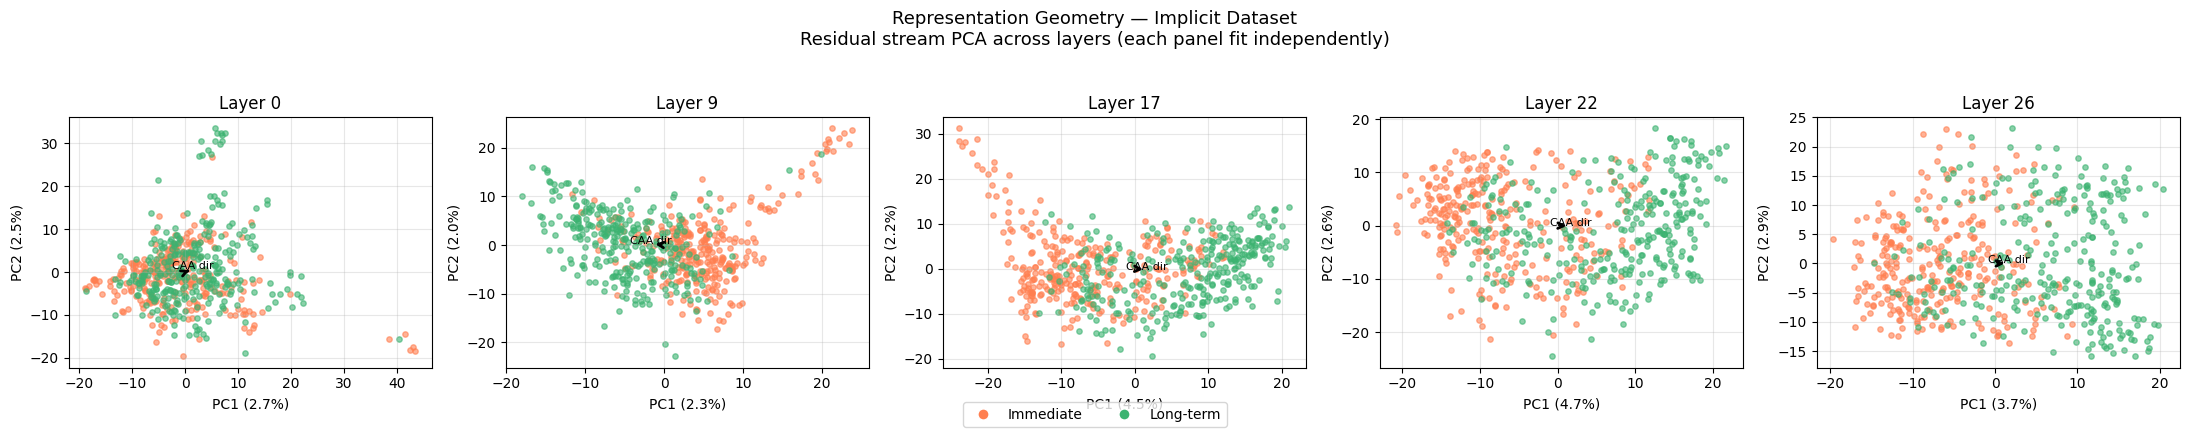

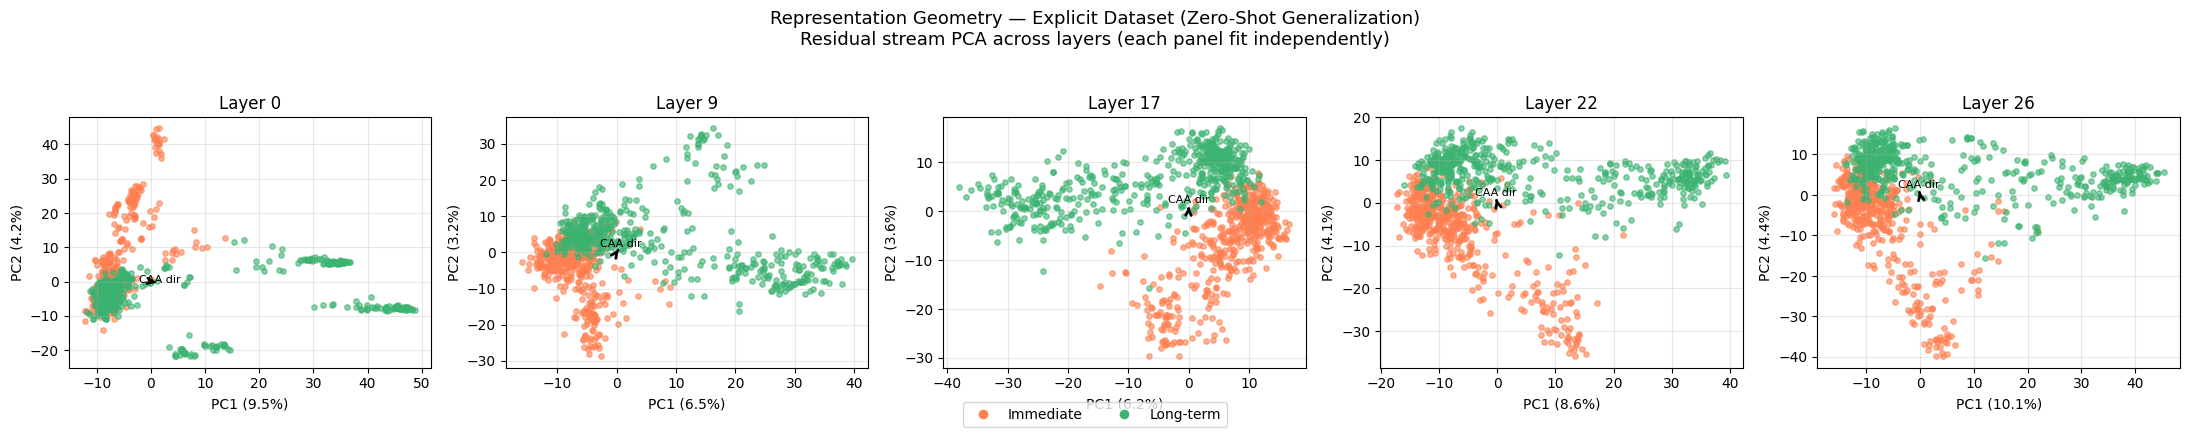

 layer  dataset PC1_var PC2_var
     0 Implicit    2.7%    2.5%
     9 Implicit    2.3%    2.0%
    17 Implicit    4.5%    2.2%
    22 Implicit    4.7%    2.6%
    26 Implicit    3.7%    2.9%
     0 Explicit    9.5%    4.2%
     9 Explicit    6.5%    3.2%
    17 Explicit    6.2%    3.6%
    22 Explicit    8.6%    4.1%
    26 Explicit   10.1%    4.4%


In [20]:
# ── Section 8.5: Representation Geometry (PCA) ───────────────────────────
from sklearn.decomposition import PCA

VIZ_LAYERS = [0, 9, 17, 22, 26]
caa_np = caa_vector_norm.cpu().numpy()

variance_table = {"layer": [], "dataset": [], "PC1_var": [], "PC2_var": []}


def _pca_panel(acts_imm, acts_lt, n_pairs, dataset_label, save_name, suptitle):
    """Draw a 5-panel PCA figure for one dataset."""
    fig, axes = plt.subplots(1, len(VIZ_LAYERS), figsize=(22, 4))

    for ax, layer in zip(axes, VIZ_LAYERS):
        X_imm = acts_imm[:, layer, :].float().numpy()
        X_lt  = acts_lt[:, layer, :].float().numpy()
        X = np.concatenate([X_imm, X_lt], axis=0)

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        pca = PCA(n_components=2)
        Z = pca.fit_transform(X_scaled)

        ax.scatter(Z[:n_pairs, 0], Z[:n_pairs, 1],
                   c="coral", alpha=0.6, s=15, label="Immediate")
        ax.scatter(Z[n_pairs:, 0], Z[n_pairs:, 1],
                   c="mediumseagreen", alpha=0.6, s=15, label="Long-term")

        # Project CAA vector using THIS panel's scaler (not the saved probe scalers)
        caa_scaled = caa_np / scaler.scale_
        caa_2d = pca.components_ @ caa_scaled
        norm = np.linalg.norm(caa_2d)
        if norm > 0:
            caa_2d = caa_2d / norm * 1.5
        ax.annotate("", xy=(caa_2d[0], caa_2d[1]), xytext=(0, 0),
                     arrowprops=dict(arrowstyle="->", color="black", lw=2))
        ax.text(caa_2d[0] * 1.1, caa_2d[1] * 1.1, "CAA dir",
                fontsize=8, ha="center", color="black")

        ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
        ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
        ax.set_title(f"Layer {layer}")
        ax.grid(alpha=0.3)

        variance_table["layer"].append(layer)
        variance_table["dataset"].append(dataset_label)
        variance_table["PC1_var"].append(f"{pca.explained_variance_ratio_[0]*100:.1f}%")
        variance_table["PC2_var"].append(f"{pca.explained_variance_ratio_[1]*100:.1f}%")

    handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="coral",
                           markersize=8, label="Immediate"),
               plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="mediumseagreen",
                           markersize=8, label="Long-term")]
    fig.legend(handles=handles, loc="lower center", ncol=2, fontsize=10,
               bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(suptitle, fontsize=13, y=1.04)
    plt.tight_layout()
    plt.savefig(PROBE_OUT_DIR / save_name, dpi=300, bbox_inches="tight")
    plt.show()


# ── Figure 1: Implicit dataset ───────────────────────────────────────────
_pca_panel(
    acts_impl_imm, acts_impl_lt, N_IMPL,
    dataset_label="Implicit",
    save_name="pca_geometry_implicit.png",
    suptitle="Representation Geometry — Implicit Dataset\n"
             "Residual stream PCA across layers (each panel fit independently)",
)

# ── Figure 2: Explicit dataset ───────────────────────────────────────────
_pca_panel(
    acts_expl_imm, acts_expl_lt, N_EXPL,
    dataset_label="Explicit",
    save_name="pca_geometry_explicit.png",
    suptitle="Representation Geometry — Explicit Dataset (Zero-Shot Generalization)\n"
             "Residual stream PCA across layers (each panel fit independently)",
)

# ── Variance summary table ───────────────────────────────────────────────
df_var = pd.DataFrame(variance_table)
print(df_var.to_string(index=False))

# Section 9 — Behavioral Layer Sweep (Forced-Choice)

For each (layer, alpha) pair we add `alpha * caa_vector_norm` to the residual
stream and measure how the model's log-probability shifts between the
**long-term** and **immediate** completions on held-out explicit prompts.

A positive score means the model now *prefers* the long-term completion — exactly
the steering effect we want.  The heatmap reveals which layer and coefficient
give the strongest, most reliable shift.

In [21]:
# ── Free probing-phase GPU memory before the sweep ────────────────────────
# The activation tensors from Sections 6-8 are no longer needed on GPU.
import gc

for _var in ['acts_impl_imm', 'acts_impl_lt', 'acts_expl_imm', 'acts_expl_lt',
             'X_impl', 'X_expl']:
    if _var in dir():
        obj = eval(_var)
        if hasattr(obj, 'cpu'):
            exec(f"{_var} = {_var}.cpu()")

gc.collect()
torch.cuda.empty_cache()

free_mem = torch.cuda.mem_get_info()[0] / 1e9
total_mem = torch.cuda.mem_get_info()[1] / 1e9
print(f"GPU memory: {free_mem:.1f} GB free / {total_mem:.1f} GB total")

GPU memory: 2.8 GB free / 12.6 GB total


=== choice_start boundary verification (first prompt) ===
choice_start = 12
     9       20162  'Ġinitiative'
    10          11  ','
    11        2908  'Ġconsider' ◄ Q END
    12          25  ':' ◄ CHOICE START
    13         320  'Ġ('
    14          32  'A'
    15           8  ')'


Baseline scores:   0%|          | 0/20 [00:00<?, ?it/s]

Baseline scores:   5%|▌         | 1/20 [00:00<00:05,  3.18it/s]

Baseline scores:  10%|█         | 2/20 [00:00<00:05,  3.16it/s]

Baseline scores:  15%|█▌        | 3/20 [00:00<00:05,  3.25it/s]

...

Layer sweep:  67%|██████▋   | 6/9 [03:07<01:33, 31.26s/it]

Layer sweep:  78%|███████▊  | 7/9 [03:38<01:02, 31.28s/it]

Layer sweep:  89%|████████▉ | 8/9 [04:10<00:31, 31.29s/it]

Layer sweep: 100%|██████████| 9/9 [04:41<00:00, 31.31s/it]

Layer sweep: 100%|██████████| 9/9 [04:41<00:00, 31.28s/it]

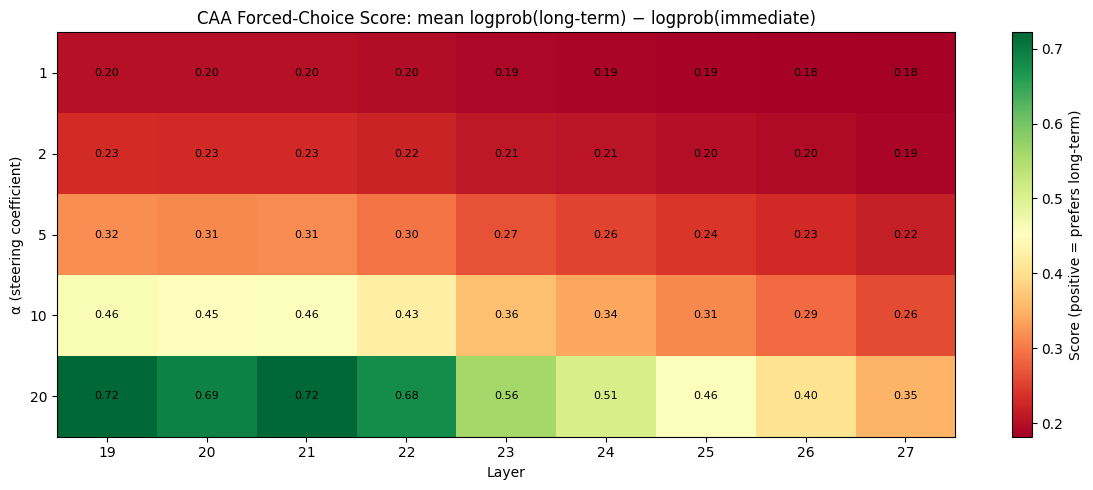


Baseline mean score : 0.1725
Best (layer, α)    : (19, 20)
Best mean score    : 0.7218
Lift over baseline : 0.5493


In [22]:
# ── Section 9: Behavioral Layer Sweep (Forced-Choice) ─────────────────────
import torch.nn.functional as F

SWEEP_LAYERS    = list(range(19, 28))
SWEEP_ALPHAS    = [1, 2, 5, 10, 20]
N_SWEEP_PROMPTS = 20

caa_vec = torch.load(PROBE_OUT_DIR / "temporal_caa_vector_norm.pt",
                     map_location=runner.device)

# ── Helper: mean log-prob of choice tokens under optional hooks ───────────
@torch.no_grad()
def score_forced_choice(input_ids_imm, input_ids_lt, choice_start_imm,
                        choice_start_lt, fwd_hooks):
    """Return mean_logprob(long_term) - mean_logprob(immediate).

    Positive = model prefers the long-term completion.
    choice_start_imm / choice_start_lt are pre-computed token positions where
    the choice text begins in each sequence (after the question tokens).
    """
    im_end_id = runner._model.tokenizer.convert_tokens_to_ids("<|im_end|>")

    scores = {}
    for tag, ids, cs in [("imm", input_ids_imm, choice_start_imm),
                         ("lt",  input_ids_lt,  choice_start_lt)]:
        logits = runner._model.run_with_hooks(ids, fwd_hooks=fwd_hooks)
        log_probs = F.log_softmax(logits[0], dim=-1)

        id_list = ids[0].tolist()
        end_pos = max(i for i, t in enumerate(id_list) if t == im_end_id)

        # Shifted teacher-forcing: logits[t] predicts token[t+1].
        # Log-probs for choice tokens at positions cs..end_pos-1
        target_ids = ids[0, cs:end_pos]
        logit_slice = log_probs[cs - 1 : end_pos - 1]
        token_log_probs = logit_slice.gather(1, target_ids.unsqueeze(1)).squeeze(1)
        scores[tag] = token_log_probs.mean().item()

        del logits, log_probs
    torch.cuda.empty_cache()

    return scores["lt"] - scores["imm"]

# ── Find user-turn start in a chat-templated token sequence ───────────────
def _find_user_turn_start(id_list):
    """Return the token index where user-turn content begins (after <|im_start|>user\\n)."""
    im_start_id = runner._model.tokenizer.convert_tokens_to_ids("<|im_start|>")
    newline_id  = runner._model.tokenizer.convert_tokens_to_ids("\n")
    for i in range(len(id_list) - 1):
        if id_list[i] == im_start_id:
            tok_str = runner._model.tokenizer.decode([id_list[i + 1]]).strip()
            if tok_str.startswith("user"):
                start = i + 2
                if start < len(id_list) and id_list[start] == newline_id:
                    start = i + 3
                return start
    raise ValueError("Could not find user turn start in token sequence")

# ── Pre-compute tokenized prompts and choice_start for N_SWEEP_PROMPTS ───
sweep_data = []

for pair in explicit_pairs[:N_SWEEP_PROMPTS]:
    q = pair["question"]
    q_len = len(runner._model.tokenizer(q, add_special_tokens=False)["input_ids"])

    imm_fmt = runner.apply_chat_template(q + pair["immediate"])
    lt_fmt  = runner.apply_chat_template(q + pair["long_term"])
    ids_imm = runner.encode(imm_fmt)
    ids_lt  = runner.encode(lt_fmt)

    cs_imm = _find_user_turn_start(ids_imm[0].tolist()) + q_len
    cs_lt  = _find_user_turn_start(ids_lt[0].tolist())  + q_len

    sweep_data.append({"ids_imm": ids_imm, "ids_lt": ids_lt,
                       "cs_imm": cs_imm, "cs_lt": cs_lt})

# ── Verify choice_start boundary on the first example ────────────────────
_ex = sweep_data[0]
_tok_list = _ex["ids_imm"][0].tolist()
_tokens = runner._model.tokenizer.convert_ids_to_tokens(_tok_list)
_cs = _ex["cs_imm"]
print("=== choice_start boundary verification (first prompt) ===")
print(f"choice_start = {_cs}")
for _j in range(max(0, _cs - 3), min(len(_tok_list), _cs + 4)):
    _marker = " ◄ CHOICE START" if _j == _cs else (" ◄ Q END" if _j == _cs - 1 else "")
    print(f"  {_j:>4}  {_tok_list[_j]:>10}  {repr(_tokens[_j])}{_marker}")

# ── Baseline scores (no hooks) ───────────────────────────────────────────
baseline_scores = []
for d in tqdm(sweep_data, desc="Baseline scores"):
    baseline_scores.append(
        score_forced_choice(d["ids_imm"], d["ids_lt"],
                            d["cs_imm"], d["cs_lt"], fwd_hooks=[])
    )
baseline_mean = float(np.mean(baseline_scores))
print(f"\nBaseline mean score (no steering): {baseline_mean:.4f}")

# ── Sweep loop ────────────────────────────────────────────────────────────
sweep_results = {}

for layer in tqdm(SWEEP_LAYERS, desc="Layer sweep"):
    for alpha in SWEEP_ALPHAS:
        hook_name = f"blocks.{layer}.hook_resid_post"
        hook_fn = (lambda value, hook, a=alpha, v=caa_vec:
                   value + a * v.to(value.device))
        fwd_hooks = [(hook_name, hook_fn)]

        scores = [score_forced_choice(d["ids_imm"], d["ids_lt"],
                                      d["cs_imm"], d["cs_lt"],
                                      fwd_hooks=fwd_hooks)
                  for d in sweep_data]
        sweep_results[(layer, alpha)] = float(np.mean(scores))

# ── Heatmap ───────────────────────────────────────────────────────────────
score_matrix = np.array([[sweep_results[(l, a)] for l in SWEEP_LAYERS]
                         for a in SWEEP_ALPHAS])

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(score_matrix, aspect="auto", cmap="RdYlGn")

ax.set_xticks(range(len(SWEEP_LAYERS)))
ax.set_xticklabels(SWEEP_LAYERS)
ax.set_yticks(range(len(SWEEP_ALPHAS)))
ax.set_yticklabels(SWEEP_ALPHAS)
ax.set_xlabel("Layer")
ax.set_ylabel("α (steering coefficient)")
ax.set_title("CAA Forced-Choice Score: mean logprob(long-term) − logprob(immediate)")

for i in range(len(SWEEP_ALPHAS)):
    for j in range(len(SWEEP_LAYERS)):
        ax.text(j, i, f"{score_matrix[i, j]:.2f}",
                ha="center", va="center", fontsize=8,
                color="black")

fig.colorbar(im, ax=ax, label="Score (positive = prefers long-term)")
plt.tight_layout()
plt.savefig(PROBE_OUT_DIR / "layer_sweep_heatmap.png", dpi=150)
plt.show()

# ── Best (layer, alpha) ──────────────────────────────────────────────────
best_idx = np.unravel_index(score_matrix.argmax(), score_matrix.shape)
best_steer_layer = SWEEP_LAYERS[best_idx[1]]
best_alpha       = SWEEP_ALPHAS[best_idx[0]]
best_score       = score_matrix[best_idx]

print(f"\nBaseline mean score : {baseline_mean:.4f}")
print(f"Best (layer, α)    : ({best_steer_layer}, {best_alpha})")
print(f"Best mean score    : {best_score:.4f}")
print(f"Lift over baseline : {best_score - baseline_mean:.4f}")

## Section 11 — Extended α Sweep (Layers 19–22)

The initial sweep (Section 9) identified the most promising layers and showed that
higher α values tend to produce stronger shifts.  This section zooms in on
layers 19–22 with larger coefficients (30, 40, 50) to find the optimal operating
point before coherence degrades.

Fine sweep (layers):   0%|          | 0/7 [00:00<?, ?it/s]

Fine sweep (layers):  14%|█▍        | 1/7 [00:18<01:53, 18.84s/it]

Fine sweep (layers):  29%|██▊       | 2/7 [00:37<01:34, 18.83s/it]

Fine sweep (layers):  43%|████▎     | 3/7 [00:56<01:15, 18.85s/it]

Fine sweep (layers):  57%|█████▋    | 4/7 [01:15<00:56, 18.82s/it]

Fine sweep (layers):  71%|███████▏  | 5/7 [01:34<00:37, 18.82s/it]

Fine sweep (layers):  86%|████████▌ | 6/7 [01:52<00:18, 18.82s/it]

Fine sweep (layers): 100%|██████████| 7/7 [02:11<00:00, 18.83s/it]

Fine sweep (layers): 100%|██████████| 7/7 [02:11<00:00, 18.83s/it]

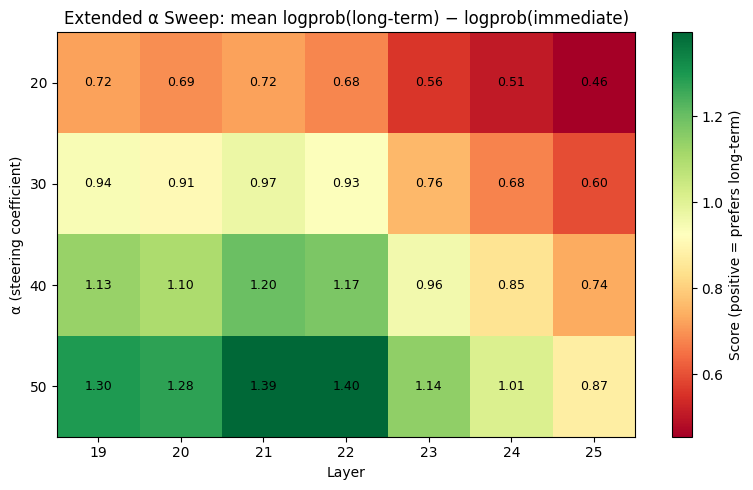

Best (layer, α)    : (22, 50)
Best mean score    : 1.3955
Baseline (Section 9): 0.1725
Lift over baseline : 1.2230


In [23]:
# ── Section 11: Extended α Sweep (Layers 19–22) ──────────────────────────
FINE_LAYERS = [19, 20, 21, 22, 23, 24, 25]
FINE_ALPHAS = [20, 30, 40, 50]

# Seed with alpha=20 results already computed in Section 9
fine_results = {}
for l in FINE_LAYERS:
    fine_results[(l, 20)] = sweep_results[(l, 20)]

# Only sweep alpha in [30, 40, 50] — 20 is already seeded
for layer in tqdm(FINE_LAYERS, desc="Fine sweep (layers)"):
    for alpha in [30, 40, 50]:
        hook_name = f"blocks.{layer}.hook_resid_post"
        hook_fn = (lambda value, hook, a=alpha, v=caa_vec:
                   value + a * v.to(value.device))
        fwd_hooks = [(hook_name, hook_fn)]

        scores = [score_forced_choice(d["ids_imm"], d["ids_lt"],
                                      d["cs_imm"], d["cs_lt"],
                                      fwd_hooks=fwd_hooks)
                  for d in sweep_data]
        fine_results[(layer, alpha)] = float(np.mean(scores))

# ── Heatmap ───────────────────────────────────────────────────────────────
fine_matrix = np.array([[fine_results[(l, a)] for l in FINE_LAYERS]
                        for a in FINE_ALPHAS])

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(fine_matrix, aspect="auto", cmap="RdYlGn")

ax.set_xticks(range(len(FINE_LAYERS)))
ax.set_xticklabels(FINE_LAYERS)
ax.set_yticks(range(len(FINE_ALPHAS)))
ax.set_yticklabels(FINE_ALPHAS)
ax.set_xlabel("Layer")
ax.set_ylabel("α (steering coefficient)")
ax.set_title("Extended α Sweep: mean logprob(long-term) − logprob(immediate)")

for i in range(len(FINE_ALPHAS)):
    for j in range(len(FINE_LAYERS)):
        ax.text(j, i, f"{fine_matrix[i, j]:.2f}",
                ha="center", va="center", fontsize=9,
                color="black")

fig.colorbar(im, ax=ax, label="Score (positive = prefers long-term)")
plt.tight_layout()
plt.savefig(PROBE_OUT_DIR / "layer_sweep_fine_heatmap.png", dpi=150)
plt.show()

# ── Update best (layer, alpha) ───────────────────────────────────────────
best_fine_idx = np.unravel_index(fine_matrix.argmax(), fine_matrix.shape)
best_steer_layer = FINE_LAYERS[best_fine_idx[1]]
best_alpha       = FINE_ALPHAS[best_fine_idx[0]]
best_fine_score  = fine_matrix[best_fine_idx]

print(f"Best (layer, α)    : ({best_steer_layer}, {best_alpha})")
print(f"Best mean score    : {best_fine_score:.4f}")
print(f"Baseline (Section 9): {baseline_mean:.4f}")
print(f"Lift over baseline : {best_fine_score - baseline_mean:.4f}")

## Section 12 — Generation Quality Sweep (Layer 22, α = 20→60)

Sweep across increasing steering coefficients on a fixed layer to find the
sweet spot where the model's framing shifts noticeably without coherence
degrading.  Baselines are generated once upfront to avoid redundant work.

In [24]:
# ── Section 10: Open-Ended Generation with Steering ──────────────────────
NEUTRAL_PROMPTS = [
    "You are advising a team on how to handle a major organizational challenge. What should be the main focus?",
    "Describe the most effective strategy for dealing with an unexpected crisis.",
    "What is the best way for a leader to respond when facing a difficult tradeoff?",
    "A nonprofit is deciding whether to expand now or build reserves. What would you suggest?",
    "How should a government respond to a growing but uncertain environmental threat?",
    "What is the wisest approach when facing a decision with irreversible consequences?",
    "A startup has limited runway and must choose between growth and profitability. What should they do?",
    "What is the most responsible way to introduce a powerful new technology?",
    "A family is deciding how to invest a sudden inheritance. What factors matter most?",
    "How should a hospital allocate scarce medical supplies during a surge?",
    "A manager must choose between short-term revenue and long-term team development. What is the right call?",
    "What is the best framework for making decisions under deep uncertainty?",
    "A researcher must decide between a safe incremental project and a risky ambitious one. What would you advise?",
]
MAX_NEW_TOKENS = 90


def generate_with_hook(prompt, fwd_hooks, max_new_tokens=MAX_NEW_TOKENS):
    """Generate text with optional activation hooks applied every step."""
    formatted  = runner.apply_chat_template(prompt)
    input_ids  = runner.encode(formatted)
    prompt_len = input_ids.shape[1]

    gen_kwargs = dict(
        max_new_tokens=max_new_tokens,
        do_sample=False,
        stop_at_eos=True,
        verbose=False,
        use_past_kv_cache=not bool(fwd_hooks),
    )

    with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
        if fwd_hooks:
            with runner._model.hooks(fwd_hooks=fwd_hooks):
                output_ids = runner._model.generate(input_ids, **gen_kwargs)
        else:
            output_ids = runner._model.generate(input_ids, **gen_kwargs)

    result = runner._model.tokenizer.decode(
        output_ids[0, prompt_len:], skip_special_tokens=True
    )
    torch.cuda.empty_cache()
    return result


# ── Section 12: Generation Quality Sweep (multi-layer, multi-α) ───────────
GEN_LAYERS = [20, 22, 23]
GEN_ALPHAS = [25, 40, 50]

# ── Generate baselines once (they never change) ──────────────────────────
print("Generating baselines …")
baselines = []
for prompt in tqdm(NEUTRAL_PROMPTS, desc="Baselines"):
    baselines.append(generate_with_hook(prompt, fwd_hooks=[]))

# ── Sweep over layers × α values ─────────────────────────────────────────
all_sweep_outputs = []

for layer in GEN_LAYERS:
    for alpha in GEN_ALPHAS:
        hook_name = f"blocks.{layer}.hook_resid_post"
        hook_fn_pos = (lambda value, hook, a=alpha, v=caa_vec:
                       value + a * v.to(value.device))
        hook_fn_neg = (lambda value, hook, a=alpha, v=caa_vec:
                       value - a * v.to(value.device))
        fwd_hooks_lt  = [(hook_name, hook_fn_pos)]
        fwd_hooks_imm = [(hook_name, hook_fn_neg)]

        print(f"\n{'═' * 46}")
        print(f"LAYER {layer}  |  α = {alpha}")
        print(f"{'═' * 46}")

        for i, prompt in enumerate(NEUTRAL_PROMPTS):
            long_term = generate_with_hook(prompt, fwd_hooks=fwd_hooks_lt)
            immediate = generate_with_hook(prompt, fwd_hooks=fwd_hooks_imm)

            all_sweep_outputs.append({
                "layer":     layer,
                "alpha":     alpha,
                "prompt":    prompt,
                "baseline":  baselines[i],
                "long_term": long_term,
                "immediate": immediate,
            })

            print(f"\n── Prompt {i+1}/{len(NEUTRAL_PROMPTS)} ──────────────────────")
            print(f"Q: {prompt}\n")
            print(f"[Baseline]        {baselines[i]}\n")
            print(f"[Long-term +{alpha}]  {long_term}\n")
            print(f"[Immediate -{alpha}]  {immediate}")

        print(f"\n→ Done layer={layer}, α={alpha}.")

# ── Save ──────────────────────────────────────────────────────────────────
with open(PROBE_OUT_DIR / "gen_quality_sweep_multilayer.json", "w") as f:
    json.dump(all_sweep_outputs, f, indent=2)

print(f"\nSaved {len(all_sweep_outputs)} outputs → {PROBE_OUT_DIR / 'gen_quality_sweep_multilayer.json'}")

Generating baselines …


Baselines:   0%|          | 0/13 [00:00<?, ?it/s]

Baselines:   8%|▊         | 1/13 [00:13<02:44, 13.73s/it]

Baselines:  15%|█▌        | 2/13 [00:27<02:30, 13.64s/it]

Baselines:  23%|██▎       | 3/13 [00:40<02:15, 13.57s/it]

...


── Prompt 9/13 ──────────────────────
Q: A family is deciding how to invest a sudden inheritance. What factors matter most?

[Baseline]        When a family is deciding how to invest a sudden inheritance, several key factors should be carefully considered to ensure the money is used wisely and aligns with the family’s long-term goals. The most important factors include:

1. **Family Financial Goals and Priorities**  
   - What are the family’s short-, medium-, and long-term goals (e.g., buying a home, funding education, retirement, starting a business)?  
   - Are

[Long-term +50]  When a family is deciding how to invest a sudden inheritance, several key factors matter to ensure long-term value, resilience, and alignment with values. Here are the most important factors:

1. **Family Goals and Values**
   - What do the family want to achieve? (e.g., wealth for future generations, financial resilience, education, sustainability)
   - Shared values (e.g., inclusivity, sustainability, int


── Prompt 10/13 ──────────────────────
Q: How should a hospital allocate scarce medical supplies during a surge?

[Baseline]        Allocating scarce medical supplies during a surge—such as during a pandemic or mass casualty event—requires a balanced, transparent, and ethically grounded approach. The goal is to maximize patient outcomes while respecting equity, fairness, and legal and moral principles. Here’s a structured framework hospitals can use:

---

### 1. **Establish Clear Criteria for Allocation**
Develop transparent, objective, and clinically relevant criteria to guide decisions. These should be based on medical

[Long-term +50]  Allocating scarce medical supplies during a surge is a complex challenge that requires balancing equity, effectiveness, evidence-based principles, and ethical values. A robust framework for such allocation should be grounded in the following principles and strategies:

1. **Evidence-Based Decision-Making**
   - Prioritize interventions supported by 


── Prompt 11/13 ──────────────────────
Q: A manager must choose between short-term revenue and long-term team development. What is the right call?

[Baseline]        The "right" call between short-term revenue and long-term team development depends on the organization's goals, stage of growth, and values—but in most sustainable and successful business contexts, **long-term team development is the better strategic choice**.

Here’s why:

### 1. **Team Development Builds Sustainable Revenue**
A strong, engaged, and skilled team is more innovative, adaptive, and efficient. This leads to:
- Higher productivity and lower turnover

[Long-term +50]  There is no single "right" answer to this question—both short-term revenue and long-term team development are essential for sustainable success. However, the *right call* depends on the context, stage of the organization, and long-term vision. Here’s how to think about it:

---

### 1. **Start with the Organization’s Stage**
- **For early-stage s


── Prompt 12/13 ──────────────────────
Q: What is the best framework for making decisions under deep uncertainty?

[Baseline]        There is no single "best" framework for making decisions under deep uncertainty, as the optimal approach depends on the context, values, stakeholders, and nature of the uncertainty. However, several well-established and widely respected frameworks have emerged as particularly effective in managing deep uncertainty—where outcomes are not only uncertain but also poorly understood, non-linear, and potentially irreversible.

Among these, the **Scenario Planning** framework (especially when combined with **robust decision-making

[Long-term +50]  There is no single "best" framework for making decisions under deep uncertainty, as the optimal approach depends on the specific context, values, goals, and available resources. However, several frameworks have emerged as particularly robust for addressing deep uncertainty—where the future is not only uncertain but a


── Prompt 13/13 ──────────────────────
Q: A researcher must decide between a safe incremental project and a risky ambitious one. What would you advise?

[Baseline]        The decision between a safe incremental project and a risky ambitious one depends on several key factors. Here’s a structured approach to help determine the best course of action:

### 1. **Assess Objectives and Goals**
- **Short-term vs. Long-term**:  
  - Incremental projects are often better for achieving short-term stability, meeting immediate needs, or building a solid foundation.  
  - Ambitious projects may be better if the goal

[Long-term +50]  To advise a researcher in choosing between a **safe incremental project** and a **risky ambitious one**, I would recommend a **context-driven, adaptive approach** that considers the following key factors:

---

### 1. **Long-Term Vision & Goals**
- **For ambitious projects**: If the goal is to transform the field, create new knowledge, or address grand challenges (e.g

In [25]:
# ── Formatted comparison tables for generation quality sweep ──────────────
from IPython.display import display, HTML

def _esc(text):
    """HTML-escape a string."""
    return (text.replace("&", "&amp;").replace("<", "&lt;")
                .replace(">", "&gt;").replace('"', "&quot;"))

layers_in_data  = sorted(set(r["layer"] for r in all_sweep_outputs))
alphas_in_data  = sorted(set(r["alpha"] for r in all_sweep_outputs))
prompts_in_data = list(dict.fromkeys(r["prompt"] for r in all_sweep_outputs))
n_cols = len(alphas_in_data) + 1

# One table per layer
for layer in layers_in_data:
    rows_html = []

    # Layer super-header
    rows_html.append(
        f'<tr><td colspan="{n_cols}" '
        f'style="background:#263238; color:white; font-weight:bold; '
        f'padding:12px; font-size:16px; text-align:center;">'
        f'Layer {layer}</td></tr>'
    )

    for pi, prompt in enumerate(prompts_in_data):
        # Prompt header
        rows_html.append(
            f'<tr><td colspan="{n_cols}" '
            f'style="background:#1565c0; color:white; font-weight:bold; '
            f'padding:10px; font-size:14px;">'
            f'Prompt {pi+1}: {_esc(prompt)}</td></tr>'
        )

        # Baseline
        baseline = next((r["baseline"] for r in all_sweep_outputs
                         if r["prompt"] == prompt and r["layer"] == layer), "")
        rows_html.append(
            '<tr><td style="background:#e3f2fd; font-weight:bold; padding:8px; '
            'width:130px; color:#0d47a1;">Baseline</td>'
            + f'<td colspan="{len(alphas_in_data)}" style="background:#e3f2fd; '
              f'color:#0d47a1; padding:8px; font-size:13px;">{_esc(baseline)}</td></tr>'
        )

        # Alpha header row
        rows_html.append(
            '<tr><td style="background:#f5f5f5; font-weight:bold; padding:6px;"></td>'
            + ''.join(
                f'<td style="background:#424242; color:white; font-weight:bold; '
                f'text-align:center; padding:6px;">α={a}</td>'
                for a in alphas_in_data)
            + '</tr>'
        )

        # Long-term row
        lt_cells = []
        for a in alphas_in_data:
            entry = next((r for r in all_sweep_outputs
                          if r["prompt"] == prompt and r["alpha"] == a
                          and r["layer"] == layer), None)
            text = _esc(entry["long_term"]) if entry else "—"
            lt_cells.append(
                f'<td style="background:#e8f5e9; color:#1b5e20; padding:8px; '
                f'font-size:13px;">{text}</td>')
        rows_html.append(
            '<tr><td style="background:#c8e6c9; font-weight:bold; padding:8px; '
            'color:#1b5e20;">Long-term (+α)</td>' + ''.join(lt_cells) + '</tr>'
        )

        # Immediate row
        imm_cells = []
        for a in alphas_in_data:
            entry = next((r for r in all_sweep_outputs
                          if r["prompt"] == prompt and r["alpha"] == a
                          and r["layer"] == layer), None)
            text = _esc(entry["immediate"]) if entry else "—"
            imm_cells.append(
                f'<td style="background:#fff3e0; color:#bf360c; padding:8px; '
                f'font-size:13px;">{text}</td>')
        rows_html.append(
            '<tr><td style="background:#ffe0b2; font-weight:bold; padding:8px; '
            'color:#bf360c;">Immediate (−α)</td>' + ''.join(imm_cells) + '</tr>'
        )

        # Spacer
        rows_html.append(
            f'<tr><td colspan="{n_cols}" '
            f'style="height:4px; background:white;"></td></tr>'
        )

    html = (
        '<div style="overflow-x:auto; margin-bottom:24px;">'
        '<table style="border-collapse:collapse; width:100%; '
        'font-family:sans-serif; font-size:13px;">'
        + ''.join(rows_html) +
        '</table></div>'
    )
    display(HTML(html))

display(HTML(
    f'<p style="color:gray; font-size:12px;">'
    f'{len(layers_in_data)} layers | {len(alphas_in_data)} α values | '
    f'{len(prompts_in_data)} prompts | '
    f'{len(all_sweep_outputs)} total outputs</p>'
))

Show Layer 19, prompt 4, alpha 50 as an example.
